In [1]:
import numpy as np
import matplotlib.pyplot as plt
from control import *
import sys
sys.path.append('../..')
from simulation.model.motor_params import *

In [2]:
# DC Motor State Space Model
# States:  x = [i, omega, theta]
# Input:   u = U (voltage)
# Output:  y = theta

A = np.array([[-R_mot/L_mot,   -Ke_mot/L_mot,  0],
              [ Kt_mot/J_mot,  -B_mot/J_mot,   0],
              [ 0,      1,     0]])

B = np.array([[1/L_mot],
              [0  ],
              [0  ]])

C = np.array([[0, 0, 1]])
D = np.array([[0]])

# Augmented model for LQI
A_aug = np.zeros((4, 4))
A_aug[:3, :3] = A
A_aug[3, 2] = -1

B_aug = np.zeros((4, 1))
B_aug[:3, :] = B

C_aug = np.array([[0, 0, 1, 0]])
D_aug = np.array([[0]])

# LQI design
Q_aug = np.diag([1, 1, 5000, 55000])
R_aug = np.array([[0.00001]])
K_aug, _, _ = lqr(A_aug, B_aug, Q_aug, R_aug)

B_ref = np.array([[0], [0], [0], [1]])
A_cl_aug = A_aug - B_aug @ K_aug
sys_lqi = ss(A_cl_aug, B_ref, C_aug, D_aug)

print('LQI ready')

LQI ready


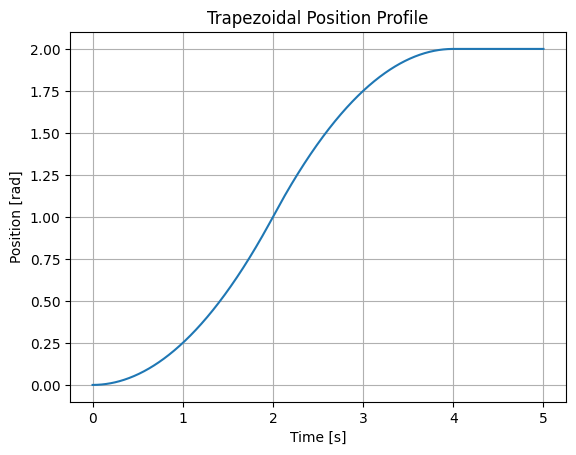

In [3]:
# Trapezoidal position profile generator
def trapezoidal_profile(t, pos_max, v_max, a_max):
    """
    Generates trapezoidal velocity profile integrated to position
    pos_max - target position [rad]
    v_max   - maximum velocity [rad/s]
    a_max   - maximum acceleration [rad/s^2]
    """
    t_acc = v_max / a_max
    t_flat = (pos_max - v_max * t_acc) / v_max
    t_flat = max(0, t_flat)
    t_total = 2 * t_acc + t_flat

    profile = np.zeros_like(t)
    for i, ti in enumerate(t):
        if ti < t_acc:
            profile[i] = 0.5 * a_max * ti**2
        elif ti < t_acc + t_flat:
            profile[i] = 0.5 * a_max * t_acc**2 + v_max * (ti - t_acc)
        elif ti < t_total:
            dt = ti - t_acc - t_flat
            profile[i] = pos_max - 0.5 * a_max * (t_acc - dt)**2
        else:
            profile[i] = pos_max
    return profile

# Generate profile
t = np.linspace(0, 5, 1000)
pos_max = 2.0    # rad
v_max = 1.0      # rad/s
a_max = 0.5      # rad/s^2

setpoint = trapezoidal_profile(t, pos_max, v_max, a_max)

plt.plot(t, setpoint)
plt.xlabel('Time [s]')
plt.ylabel('Position [rad]')
plt.title('Trapezoidal Position Profile')
plt.grid(True)
plt.show()

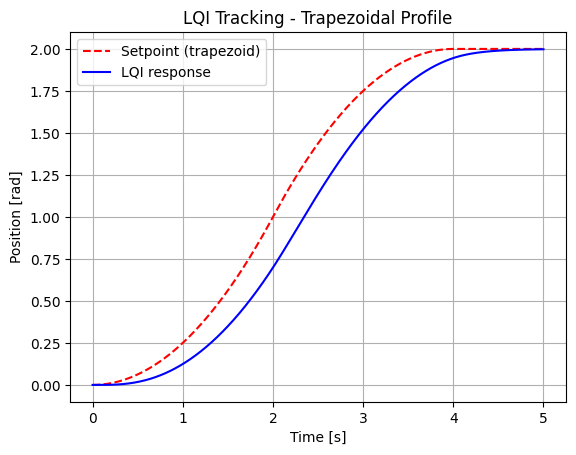

In [4]:
# Simulate LQI tracking of trapezoidal profile
t_out, y_out = forced_response(sys_lqi, T=t, U=setpoint)

plt.plot(t, setpoint, 'r--', label='Setpoint (trapezoid)')
plt.plot(t_out, y_out, 'b', label='LQI response')
plt.xlabel('Time [s]')
plt.ylabel('Position [rad]')
plt.title('LQI Tracking - Trapezoidal Profile')
plt.legend()
plt.grid(True)
plt.show()

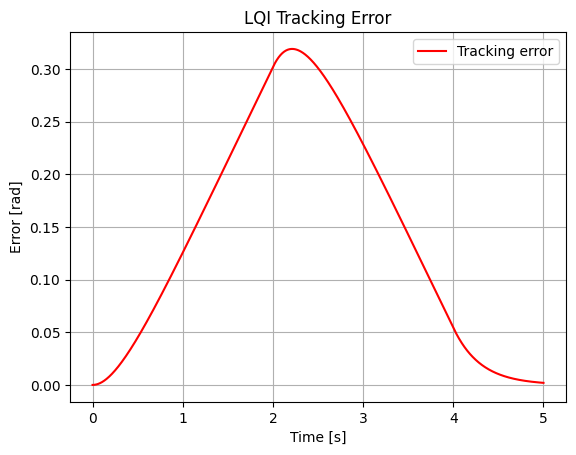

Max error: 0.3189 rad
Steady state error: 0.0020 rad


In [5]:
# Tracking error
error = setpoint - y_out

plt.plot(t, error, 'r', label='Tracking error')
plt.xlabel('Time [s]')
plt.ylabel('Error [rad]')
plt.title('LQI Tracking Error')
plt.legend()
plt.grid(True)
plt.show()

print(f'Max error: {np.max(np.abs(error)):.4f} rad')
print(f'Steady state error: {np.abs(error[-1]):.4f} rad')